
[baseline] Loading config from ./configs/model_45M.json...
[baseline] Measuring FLOPs vs C...
[baseline] Measuring FLOPs vs T...

[only bias] Loading config from ./configs/model_45M_bias.json...
[only bias] Measuring FLOPs vs C...
[only bias] Measuring FLOPs vs T...

[only div] Loading config from ./configs/model_45M_div.json...
[only div] Measuring FLOPs vs C...
[only div] Measuring FLOPs vs T...

[only full] Loading config from ./configs/model_45M_full.json...
[only full] Measuring FLOPs vs C...
[only full] Measuring FLOPs vs T...

[spat off] Loading config from ./configs/model_45M_spOff.json...
[spat off] Measuring FLOPs vs C...
[spat off] Measuring FLOPs vs T...

[200m] Loading config from ./configs/model_200M.json...
[200m] Measuring FLOPs vs C...
[200m] Measuring FLOPs vs T...

[20m] Loading config from ./configs/model_20M.json...
[20m] Measuring FLOPs vs C...
[20m] Measuring FLOPs vs T...

All measurements complete. Plotting...


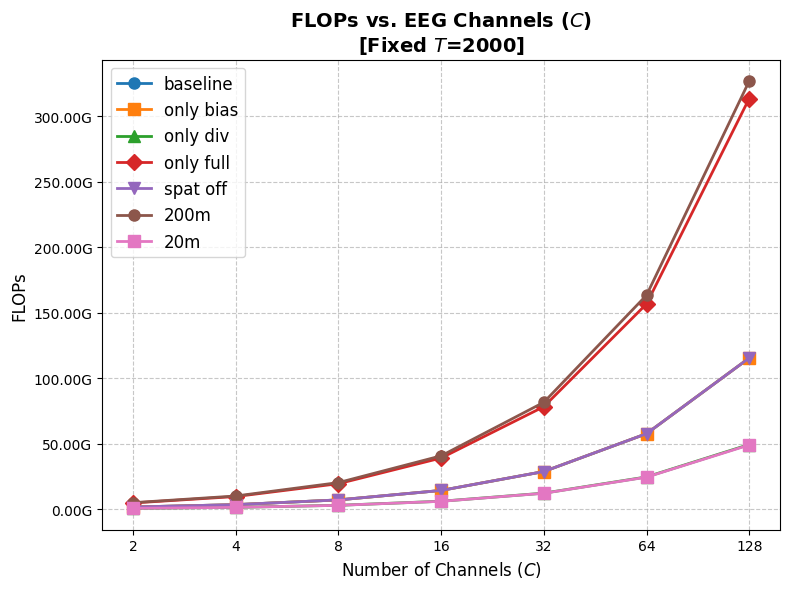

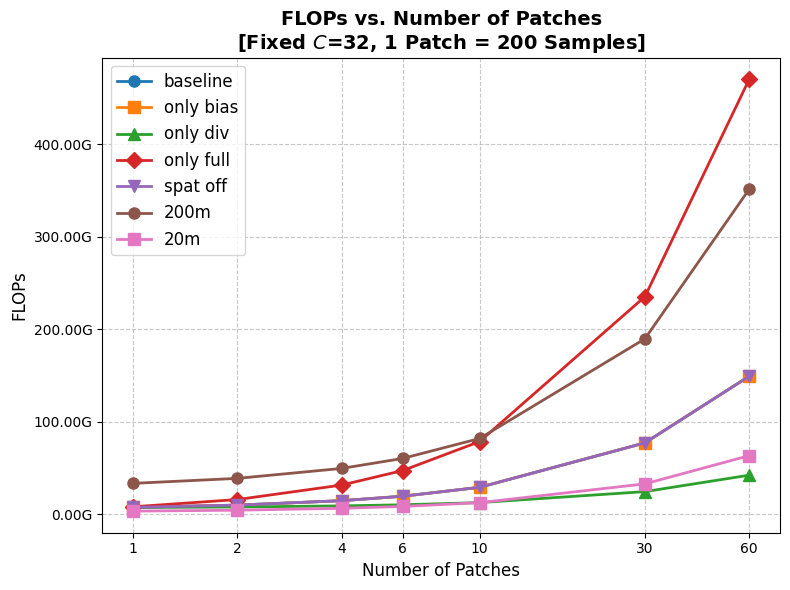

In [12]:
import torch
import matplotlib.pyplot as plt
from thop import profile

# --- 사용자 제공 모듈 임포트 ---
from model import EEGEncoder, CrossAttentionPredictor
from config import EEGModelConfig

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 1. 유틸리티 함수 및 Wrapper (이전과 동일) ---
def gather_channel_embeddings(x: torch.Tensor, c_idx: torch.Tensor, pad: torch.Tensor) -> torch.Tensor:
    B, C, D = x.shape
    B2, L = c_idx.shape
    assert B == B2
    idx = c_idx[..., None].expand(B, L, D)
    out = x.gather(dim=1, index=idx)
    return out.masked_fill(pad[..., None], 0.0)

class ExactEEGJEPAWrapper(torch.nn.Module):
    def __init__(self, student, teacher, predictor):
        super().__init__()
        self.student = student
        self.teacher = teacher
        self.predictor = predictor

    def forward(self, x, coords, c_ctx, t_ctx, pad_ctx, c_tgt, t_tgt, pad_tgt):
        B = x.shape[0]
        dummy_freq_drop = torch.zeros(B, dtype=torch.bool, device=x.device)

        coord_ch_student = self.student.coord_embed(coords)
        tok_ctx, pad_ctx_out, rope_ctx, chan_ctx = self.student.embed_from_indices(
            x=x, coords=coords, c_idx=c_ctx, t_idx=t_ctx, pad=pad_ctx,
            coord_ch=coord_ch_student, freq_mask_bins=None, freq_domain_drop=dummy_freq_drop
        )
        z_ctx = self.student(tok_ctx, padding_mask=pad_ctx_out, rope_pos=rope_ctx, chan_idx=chan_ctx, coords=coords)

        with torch.no_grad():
            coord_ch_teacher = self.teacher.coord_embed(coords)
            tok_tgt, pad_tgt_out, rope_tgt, chan_tgt = self.teacher.embed_from_indices(
                x=x, coords=coords, c_idx=c_tgt, t_idx=t_tgt, pad=pad_tgt,
                coord_ch=coord_ch_teacher, freq_mask_bins=None, freq_domain_drop=None
            )
            z_tgt = self.teacher(tok_tgt, padding_mask=pad_tgt_out, rope_pos=rope_tgt, chan_idx=chan_tgt, coords=coords)

        coord_tgt = gather_channel_embeddings(coord_ch_student, c_tgt.clamp(min=0), pad_tgt)

        pred_tgt = self.predictor(
            ctx=z_ctx, ctx_pad=pad_ctx_out, rope_ctx=rope_ctx,
            tgt_coord_emb=coord_tgt, tgt_pad=pad_tgt, rope_tgt=rope_tgt
        )
        return pred_tgt

def get_dummy_inputs(B, C, T, device):
    x = torch.randn(B, C, T).to(device)
    coords = torch.randn(B, C, 3).to(device)
    
    L_ctx = max(1, int((C * T) * 0.01))
    L_tgt = max(1, int((C * T) * 0.005))
    
    c_ctx = torch.zeros((B, L_ctx), dtype=torch.long).to(device)
    t_ctx = torch.zeros((B, L_ctx), dtype=torch.long).to(device)
    pad_ctx = torch.zeros(B, L_ctx).bool().to(device)
    
    c_tgt = torch.zeros((B, L_tgt), dtype=torch.long).to(device)
    t_tgt = torch.zeros((B, L_tgt), dtype=torch.long).to(device)
    pad_tgt = torch.zeros(B, L_tgt).bool().to(device)
    
    return (x, coords, c_ctx, t_ctx, pad_ctx, c_tgt, t_tgt, pad_tgt)

# --- 2. 실험 세팅 및 여러 모델 정의 ---
B = 1
fixed_T = 2000  
fixed_C = 32    

C_list = [2, 4, 8, 16, 32, 64, 128]
T_list = [200, 400, 800, 1200, 2000, 6000, 12000]
patch_list = [t / 200 for t in T_list] # 1 Patch = 200 Samples

# [핵심 추가] 비교할 모델들의 이름과 설정 파일 경로를 딕셔너리로 정의합니다.
model_configs = {
    "baseline": "./configs/model_45M.json",
    "only bias": "./configs/model_45M_bias.json",
    "only div": "./configs/model_45M_div.json",
    "only full": "./configs/model_45M_full.json",
    "spat off": "./configs/model_45M_spOff.json",
    "200m": "./configs/model_200M.json",
    "20m": "./configs/model_20M.json",
}

# 결과를 저장할 딕셔너리
results_C = {}
results_T = {}

# --- 3. 모델 순회하며 FLOPs 측정 ---
for model_name, config_path in model_configs.items():
    print(f"\n[{model_name}] Loading config from {config_path}...")
    
    # 모델 로드 (각 루프마다 새로운 모델 객체 생성)
    model_cfg = EEGModelConfig.from_json(config_path)
    student = EEGEncoder(model_cfg).to(device)
    teacher = EEGEncoder(model_cfg).to(device)
    predictor = CrossAttentionPredictor(model_cfg).to(device)
    
    model = ExactEEGJEPAWrapper(student, teacher, predictor)
    model.eval()
    
    flops_C, flops_T = [], []
    
    print(f"[{model_name}] Measuring FLOPs vs C...")
    for C in C_list:
        inputs = get_dummy_inputs(B, C, fixed_T, device)
        macs, _ = profile(model, inputs=inputs, verbose=False)
        flops_C.append(macs * 2)
        
    print(f"[{model_name}] Measuring FLOPs vs T...")
    for T in T_list:
        inputs = get_dummy_inputs(B, fixed_C, T, device)
        macs, _ = profile(model, inputs=inputs, verbose=False)
        flops_T.append(macs * 2)
        
    # 결과 저장
    results_C[model_name] = flops_C
    results_T[model_name] = flops_T

print("\nAll measurements complete. Plotting...")

# --- 4. 시각화 (여러 선 그리기) ---
# 시각화 구분을 위한 마커 리스트 (모델이 늘어날 경우를 대비)
markers = ['o', 's', '^', 'D', 'v']

# Figure 1: C에 따른 FLOPs (여러 모델)
plt.figure(figsize=(8, 6))
for i, (model_name, flops) in enumerate(results_C.items()):
    plt.plot(C_list, flops, marker=markers[i % len(markers)], linewidth=2, markersize=8, label=model_name)

plt.title(f'FLOPs vs. EEG Channels ($C$)\n[Fixed $T$={fixed_T}]', fontsize=14, fontweight='bold')
plt.xlabel('Number of Channels ($C$)', fontsize=12)
plt.ylabel('FLOPs', fontsize=12)
plt.xscale('log', base=2)
plt.xticks(C_list, labels=[str(c) for c in C_list])
plt.grid(True, linestyle='--', alpha=0.7)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,.2f}G".format(x/1e9))) 
plt.legend(fontsize=12) # [핵심 추가] 범례 표시
plt.tight_layout()
plt.savefig('flops_vs_C_MultiModel.png', dpi=300)
plt.show()

# Figure 2: 패치 수에 따른 FLOPs (여러 모델)
plt.figure(figsize=(8, 6))
for i, (model_name, flops) in enumerate(results_T.items()):
    plt.plot(patch_list, flops, marker=markers[i % len(markers)], linewidth=2, markersize=8, label=model_name)

plt.title(f'FLOPs vs. Number of Patches\n[Fixed $C$={fixed_C}, 1 Patch = 200 Samples]', fontsize=14, fontweight='bold')
plt.xlabel('Number of Patches', fontsize=12)
plt.ylabel('FLOPs', fontsize=12)
plt.xscale('log', base=2)
plt.xticks(patch_list, labels=[f"{p:g}" for p in patch_list])
plt.grid(True, linestyle='--', alpha=0.7)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,.2f}G".format(x/1e9)))
plt.legend(fontsize=12) # [핵심 추가] 범례 표시
plt.tight_layout()
plt.savefig('flops_vs_Patches_MultiModel.png', dpi=300)
plt.show()